# Fisher analysis for PS_2D

Follows Sambit's notebook closely, but does some wedge cuts.

This is somewhat of a HERA-style foreground avoidance treatment of the impact of foregrounds and systematics. We look at parameter constraints under different foreground wedge cuts, which are rough analogs for the severity of foregrounds / systematics and our ability to model / subtract them in the data.

1. Compute the 2D power spectra of the provided lightcones after applying the PSF beam smoothing (and optionally injecting thermal noise given an array layout and observation integration time).
2. Cut the 2D power spectra based on different assumptions of foreground subtraction and systematics.
    1. Perfect foreground removal (i.e. no wedge cut)
    2. Foreground cut out to 2 * 10 degree FWHM of primary beam (i.e. primary beam wedge)
    3. Foreground cut out to horizon (i.e. standard horizon wedge)
3. Flatten the 2D power spectra and compute the Fisher matrix.

Created 10/2025, Nick Kern (nkern@umich.edu)

In [1]:
%matplotlib inline
import numpy as np
import h5py
import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
import corner
from scipy.signal import windows

import os
import glob
import numpy as np

import tools21cm as t2c

In [2]:
from astropy.cosmology import Planck18 as cos

In [3]:
from utils import tau_to_kpara, bl_to_kperp

In [4]:
output_stat_dir = './SKA_chapter_statistics/'

In [5]:
statname = 'ps'

In [252]:
telescope_type = "AA4"
obs_time = 1000

In [253]:
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']

In [254]:
# Construct the list of statistic files to loop over
files = [f'{output_stat_dir}{statname}_FID_400_Samples_{telescope_type}_{int(obs_time)}h.h5']
for p in params:
    files.extend([
        f'{output_stat_dir}{statname}_{p}_400_Samples_Plus_{telescope_type}_{int(obs_time)}h.h5',
        f'{output_stat_dir}{statname}_{p}_400_Samples_Minus_{telescope_type}_{int(obs_time)}h.h5'
    ])
print(files)

['./SKA_chapter_statistics/ps_FID_400_Samples_AA4_1000h.h5', './SKA_chapter_statistics/ps_ION_Tvir_MIN_400_Samples_Plus_AA4_1000h.h5', './SKA_chapter_statistics/ps_ION_Tvir_MIN_400_Samples_Minus_AA4_1000h.h5', './SKA_chapter_statistics/ps_R_BUBBLE_MAX_400_Samples_Plus_AA4_1000h.h5', './SKA_chapter_statistics/ps_R_BUBBLE_MAX_400_Samples_Minus_AA4_1000h.h5', './SKA_chapter_statistics/ps_HII_EFF_FACTOR_400_Samples_Plus_AA4_1000h.h5', './SKA_chapter_statistics/ps_HII_EFF_FACTOR_400_Samples_Minus_AA4_1000h.h5']


In [255]:
# cosmology
h = 0.6774

In [256]:
# get kper and kpar
nbins = 15

# load 21cm brightness lightcone
ddir = '../../SKA_Chapter_simulations/' # This folder can be created inside the repository folder. It will be ignored during the git commit.
_dfiles = np.sort(glob.glob(ddir+'Lightcone*h5'))

with h5py.File(_dfiles[0], 'r') as f:
    data = f['brightness_lightcone'][0]
    redshifts = f['redshifts'][...]
    box_length = float(f['box_length'][0]) / h  # Mpc
    box_dim = int(f['ngrid'][0])
    ngrid = int(f['ngrid'][0])  # number of pixels along the sky patch
    n_samp = int(f['nrealisations'][0])
    
cdists = cos.comoving_distance(redshifts)
box_length_los = (cdists.max()-cdists.min()).value
box_length_list = [box_length, box_length, box_length_los]

# need to move it to the first axis to match t21c
data = np.moveaxis(data, 0, 2)

# estimate ps and get kpers and kpars
ps_est, kpers, kpars = t2c.power_spectrum_2d(
    data,
    kbins=nbins,
    box_dims=box_length_list
)
kpers, kpars = np.meshgrid(kpers, kpars, indexing='ij')
kpers, kpars = kpers.ravel(), kpars.ravel()
ks = np.sqrt(kpers.ravel()**2 + kpars.ravel()**2)

In [257]:
dk = 2.*np.pi/box_length
k_nyquist = dk*box_dim/2.

In [258]:
# Astro params
nparams = len(params)
# parameter values for fiducial simulation
fid = [pow(10,4.7),15,30]
# parameter range for derivatives
delta_params = [pow(10,4.740362689494244)-pow(10,4.653212513775344), 10, 10]

In [259]:
# Construct the list of statistic files to loop over
files = [f'{output_stat_dir}{statname}_FID_400_Samples_{telescope_type}_{int(obs_time)}h.h5']
for p in params:
    files.extend([
        f'{output_stat_dir}{statname}_{p}_400_Samples_Plus_{telescope_type}_{int(obs_time)}h.h5',
        f'{output_stat_dir}{statname}_{p}_400_Samples_Minus_{telescope_type}_{int(obs_time)}h.h5'
    ])
print(files)

['./SKA_chapter_statistics/ps_FID_400_Samples_AA4_1000h.h5', './SKA_chapter_statistics/ps_ION_Tvir_MIN_400_Samples_Plus_AA4_1000h.h5', './SKA_chapter_statistics/ps_ION_Tvir_MIN_400_Samples_Minus_AA4_1000h.h5', './SKA_chapter_statistics/ps_R_BUBBLE_MAX_400_Samples_Plus_AA4_1000h.h5', './SKA_chapter_statistics/ps_R_BUBBLE_MAX_400_Samples_Minus_AA4_1000h.h5', './SKA_chapter_statistics/ps_HII_EFF_FACTOR_400_Samples_Plus_AA4_1000h.h5', './SKA_chapter_statistics/ps_HII_EFF_FACTOR_400_Samples_Minus_AA4_1000h.h5']


In [260]:
# container dict: keys will be e.g. 'PS_param_1_plus', 'PS_fid', etc.
PS_data = {}
keys = []
count = 0
for fpath in tqdm.tqdm(files):

    key = os.path.basename(fpath).replace(f'{statname}_', '').replace(f'_400_Samples', '').replace(f'_{telescope_type}_{int(obs_time)}h.h5', '')
    keys.append(key)
    try:
        with h5py.File(fpath, 'r') as f:
            ks = f['bins'][...]
            mask = ks < k_nyquist
            PS_data[key] = {
                'ps_clean':  f['clean'][:, mask],  # ps of clean cosmological signal
                'ks':  f['bins'][mask],
            }
            if 'FID' in key:
                PS_data[key].update({
                    'ps_noise':  f['noise'][:, mask],  # ps of noise
                    'ps_obs':  f['obs'][:, mask],  # ps of smoothed (noise + cosmological signal)
                })
    except KeyError as e:
        print(f"KeyError: {e} in file {fpath}. Initializing empty data.")
        PS_data[key] = {}
        PS_data[key]['ps_clean'] = np.zeros((n_samp, nbins))
        PS_data[key]['ps_noise'] = np.zeros((n_samp, nbins))
        PS_data[key]['ps_obs'] = np.zeros((n_samp, nbins))
        PS_data[key]['ks'] = np.zeros(nbins)
        count += 1

# now you can refer to, e.g. PS_data['PS_R_BUBBLE_MAX_plus']['PS'] 
# and PS_data['PS_R_BUBBLE_MAX_plus']['ks'] etc.
print(f'Found {len(PS_data)} {statname} datasets, {count} missing.')

# Example: check shapes
for name, dat in PS_data.items():
    print(f"{name:25s} → PS {dat['ps_clean'].shape},  ks {dat['ks'].shape}")

100%|██████████| 7/7 [00:00<00:00, 360.54it/s]

Found 7 ps datasets, 0 missing.
FID                       → PS (400, 194),  ks (194,)
ION_Tvir_MIN_Plus         → PS (400, 194),  ks (194,)
ION_Tvir_MIN_Minus        → PS (400, 194),  ks (194,)
R_BUBBLE_MAX_Plus         → PS (400, 194),  ks (194,)
R_BUBBLE_MAX_Minus        → PS (400, 194),  ks (194,)
HII_EFF_FACTOR_Plus       → PS (400, 194),  ks (194,)
HII_EFF_FACTOR_Minus      → PS (400, 194),  ks (194,)


In [261]:
# get unmasked (i.e. non-zero variance) modes
kpers, kpars, ps_est = kpers[mask], kpars[mask], ps_est.ravel()[mask]

In [262]:
# Compute the finite‐difference derivatives for each k‐bin & sample
# from the statistics derived from the clean signal
dPS = {}
PS_derivs = np.zeros((len(params), n_samp, mask.sum()))
for ip, param in enumerate(params):
    dPS[param] = (PS_data[f'{param}_Plus']['ps_clean'] - PS_data[f'{param}_Minus']['ps_clean']) / delta_params[ip]
    PS_derivs[ip] = (PS_data[f'{param}_Plus']['ps_clean'] - PS_data[f'{param}_Minus']['ps_clean']) / delta_params[ip]
ks = PS_data[f'{param}_Plus']['ks']

print(dPS['R_BUBBLE_MAX'].shape)

(400, 194)


In [263]:
## Whitening step ##
PS_fid = PS_data['FID']['ps_obs'] 
std_fid = np.std(PS_fid, axis=0)
#std_fid = np.median(np.abs(PS_fid - np.median(PS_fid, axis=0)), axis=0)

# remove modes above smoothing limit where there is no variance
mask = std_fid > 1e-1
white_fid = PS_fid[:, mask]/std_fid[mask]
kbins = PS_data['FID']['ks'][mask]
# Whitening the derivatives
PS_derivs_white = PS_derivs[..., mask]/std_fid[mask]
kper, kpar = kpers[mask], kpars[mask]

print("Nmodes:", kbins.size)

Nmodes: 125


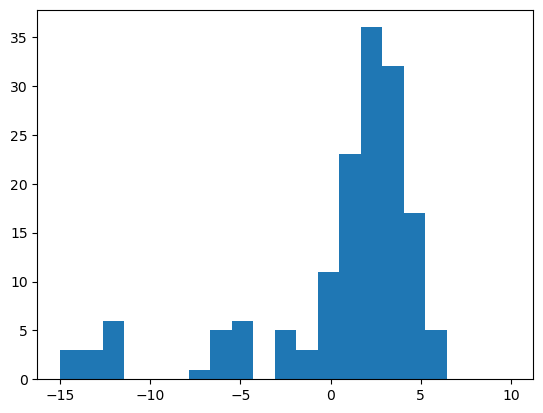

In [264]:
# plot std_fid
plt.hist(np.log10(std_fid), range=(-15, 10), bins=21);

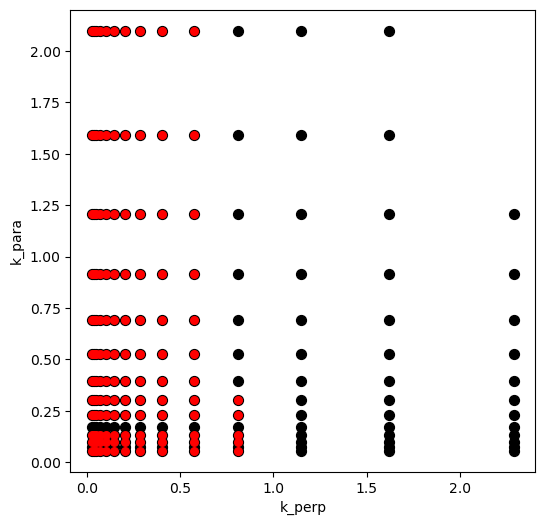

In [265]:
# plot the modes that are kept (red)
plt.figure(figsize=(6, 6))
plt.scatter(kpers, kpars, c='k', s=50)
plt.scatter(kpers[mask], kpars[mask], c='r', s=30)
plt.xlabel('k_perp'); plt.ylabel('k_para');

In [266]:
covariance = np.cov(white_fid, rowvar=False)
# Check the condition of the covariance to ensure numerical inversion is stable:
print(f'log Condition number of the covariance matrix: {np.log10(np.linalg.cond(covariance)):.2f} (should be <= 7).')

log Condition number of the covariance matrix: 2.98 (should be <= 7).


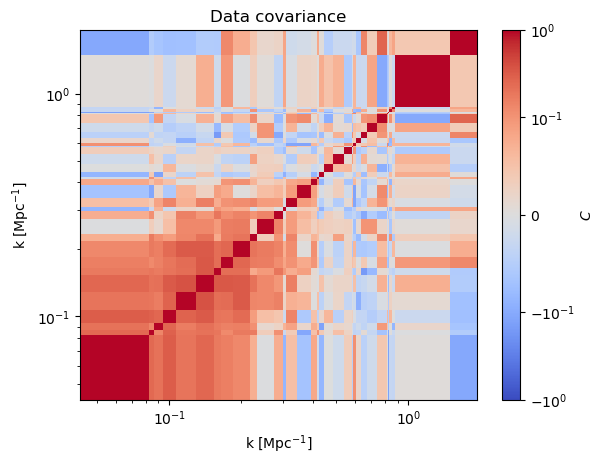

In [267]:
plt.figure()
plt.pcolormesh(kbins, kbins, covariance, cmap='coolwarm', norm=colors.SymLogNorm(linthresh=.1, vmin=-1., vmax=1.))
plt.xscale('log')
plt.yscale('log')
plt.title('Data covariance')
plt.xlabel('k [Mpc$^{-1}$]')
plt.ylabel('k [Mpc$^{-1}$]')
plt.colorbar(label=r'$C$')

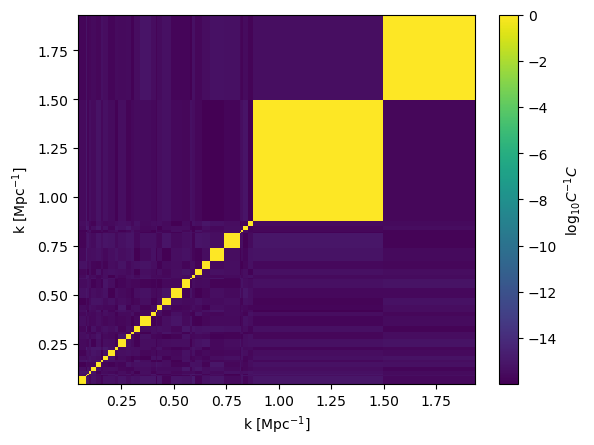

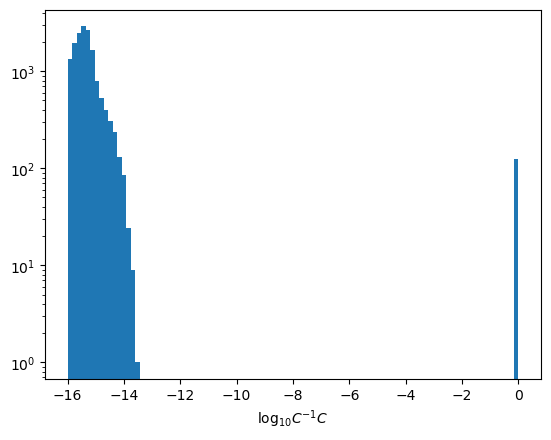

In [268]:
# Checking stability of the covariance by looking at the value of the off-diagonal terms of Sigma dot Sigma-1
I = np.log10(abs(np.matmul(np.linalg.pinv(covariance), covariance))+1e-16)

plt.figure()
plt.pcolormesh(kbins, kbins, I)
plt.colorbar().set_label('log$_{10} C^{-1}C$')
plt.xlabel('k [Mpc$^{-1}$]')
plt.ylabel('k [Mpc$^{-1}$]')

plt.figure()
plt.hist(I[I!=1.].reshape(-1), bins=100)
plt.xlabel('log$_{10} C^{-1}C$')
plt.yscale('log')

In [269]:
z0 = redshifts.mean()
kper_2_kpar = tau_to_kpara(z0, cos) / bl_to_kperp(z0, cos) / 2.99e8

# define wedge cuts
kpar_no_wedge = np.zeros_like(kper)  # no wedge
kpar_beam_wedge = kper * kper_2_kpar * np.sin(10 * np.pi / 180)  # PB wedge
kpar_horizon_wedge = kper * kper_2_kpar * np.sin(90 * np.pi / 180)  # horizon wedge

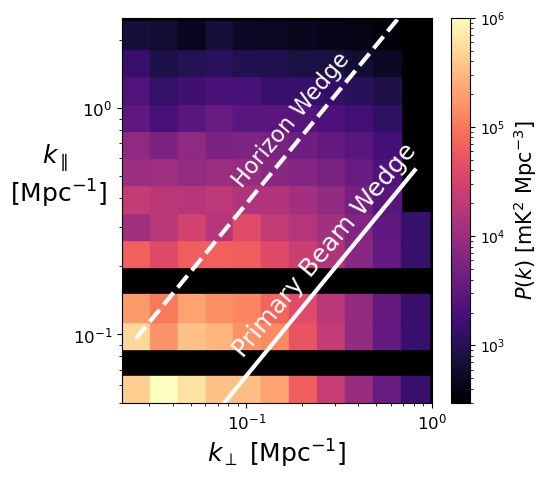

In [270]:
# plot the fiducial PS with wedge cuts
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(labelsize=12)
cax = ax.scatter(kper, kpar, c=ps_est[mask], marker='s', s=400,
                 norm=colors.LogNorm(vmin=3e2, vmax=1e6), cmap='magma')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$k_\perp$ [Mpc$^{-1}$]', fontsize=18);
ax.set_ylabel('$k_\parallel$ \n[Mpc$^{-1}$]', fontsize=18, rotation=0, labelpad=10)
ax.set_xlim(None, 1e0); ax.set_ylim(5e-2, None)
ax.set_facecolor('k')
cbar = fig.colorbar(cax)
cbar.set_label(r'$P(k)$ [mK$^2$ Mpc$^{-3}$]', fontsize=15)
ax.plot(kper, kpar_beam_wedge, c='w', lw=3, )
ax.plot(kper, kpar_horizon_wedge, c='w', lw=3, ls='--')
ax.text(.08, .08, 'Primary Beam Wedge', fontsize=18, c='w', rotation=50)
ax.text(.08, .45, 'Horizon Wedge', fontsize=16, c='w', rotation=50);

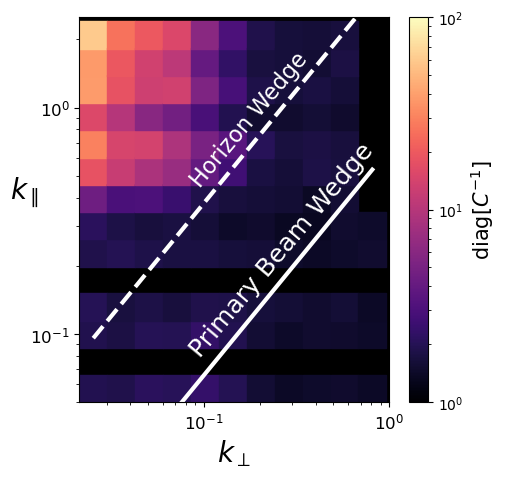

In [271]:
# plot the (std_fid whitened) inverse covariance
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(labelsize=12)
cax = ax.scatter(kper, kpar, c=np.linalg.inv(covariance).diagonal(), marker='s', s=400,
                 norm=colors.LogNorm(vmin=1e0, vmax=1e2), cmap='magma')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$k_\perp$', fontsize=20); ax.set_ylabel(r'$k_\parallel$', fontsize=20, rotation=0)
ax.set_xlim(None, 1e0); ax.set_ylim(5e-2, None)
ax.set_facecolor('k')
cbar = fig.colorbar(cax)
cbar.set_label(r'diag[$C^{-1}$]', fontsize=15)
ax.plot(kper, kpar_beam_wedge, c='w', lw=3, )
ax.plot(kper, kpar_horizon_wedge, c='w', lw=3, ls='--')
ax.text(.08, .08, 'Primary Beam Wedge', fontsize=18, c='w', rotation=50)
ax.text(.08, .45, 'Horizon Wedge', fontsize=16, c='w', rotation=50);

In [272]:
# Number of realisations to look at when checking convergence
samples = np.arange(5, n_samp+5, 5)

# Initialising Fishers 
PS_Fisher = np.zeros((samples.size, nparams, nparams))
PS_Fisher_Inv = np.zeros((samples.size, nparams, nparams))

In [278]:
# set the wedge cut
kcut = kpar > kpar_horizon_wedge

In [279]:
# Calculating the Fisher matrix for a given sample of derivatives 
for k, sample_size in enumerate(samples):
    deriv_sample = np.mean(PS_derivs_white[:, :sample_size, :], axis=1)
    
    deriv_sample = deriv_sample[:, kcut]
    Cinv = np.linalg.inv(covariance[kcut][:, kcut])#, hermitian=True)
    
    for i in range(nparams):
        for j in range(nparams):  
            PS_Fisher[k, i, j] = deriv_sample[i] @ Cinv @ deriv_sample[j]
    PS_Fisher_Inv[k] = np.linalg.inv(PS_Fisher[k])

Text(0.5, 1.0, 'Convergence of the Fisher inverse matrix diagonal elements')

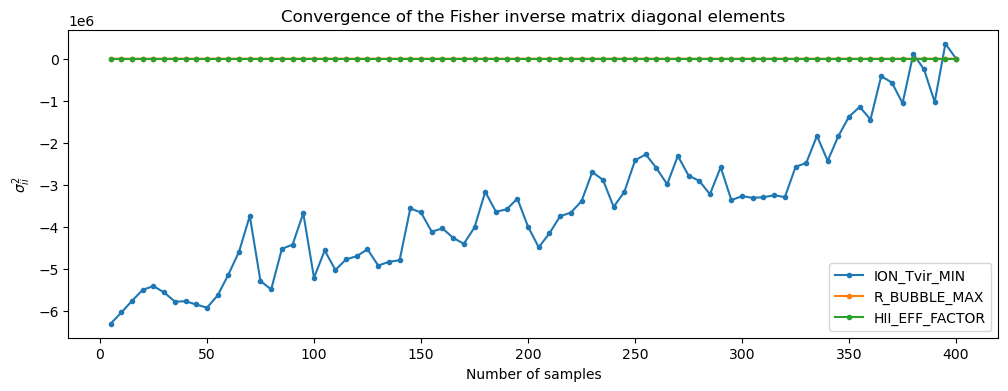

In [280]:
plt.figure(figsize=(12, 4))
for i, param in enumerate(params[:]):
    plt.plot(samples, [np.diag(PS_Fisher_Inv[k])[i]-np.diag(PS_Fisher_Inv[-1])[i] for k in range(samples.size)], marker='.', label=param)
plt.legend()
plt.ylabel(r'$\sigma^2_{ii}$')
plt.xlabel('Number of samples')
plt.title('Convergence of the Fisher inverse matrix diagonal elements')

# no wedge

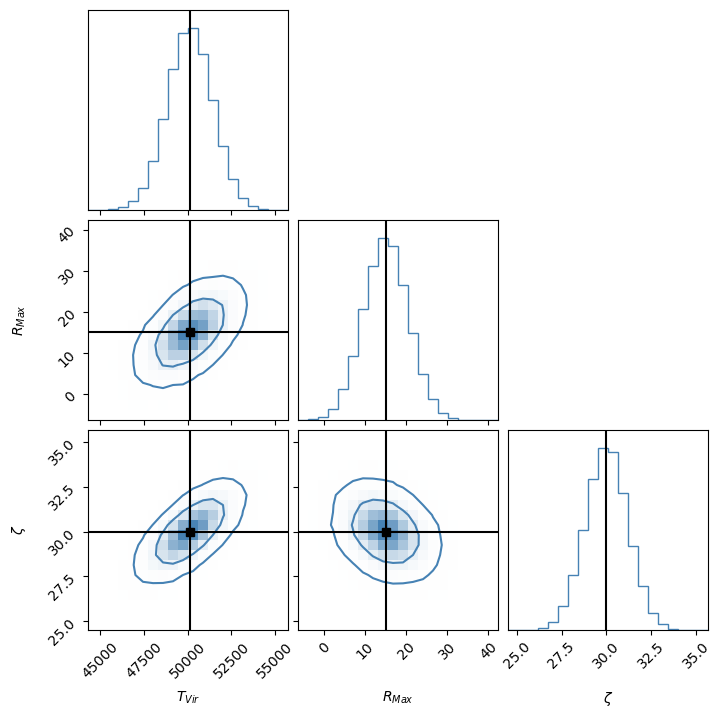

In [206]:
fisher_samples_AAstar_100h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AAstar_100h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='steelblue'           
)

In [207]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_no_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AAstar_100hours_ps2d_no_wedge.txt


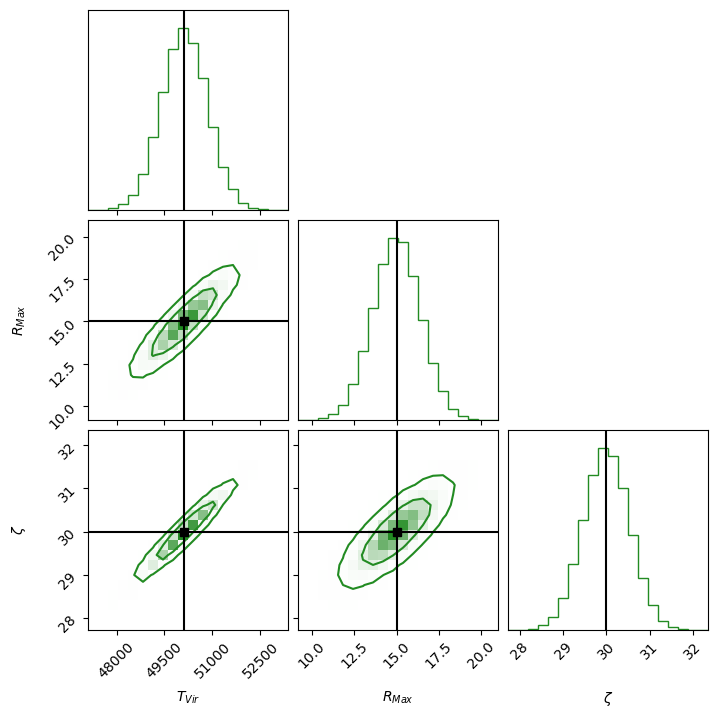

In [153]:
fisher_samples_AAstar_1000h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AAstar_1000h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='forestgreen'           
)

In [154]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_no_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AAstar_1000hours_ps2d_no_wedge.txt


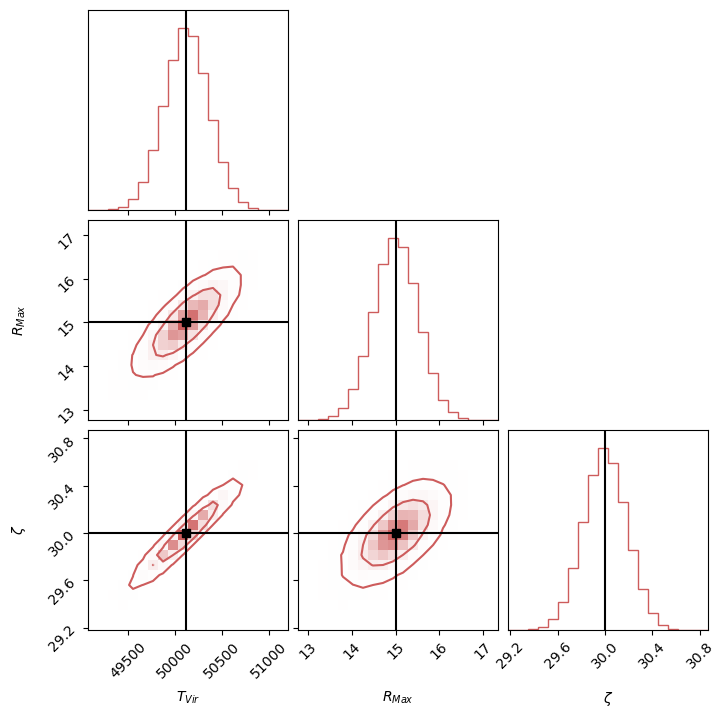

In [179]:
fisher_samples_AA4_1000h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AA4_1000h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='indianred'           
)

In [180]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_no_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AA4_1000hours_ps2d_no_wedge.txt


# beam wedge

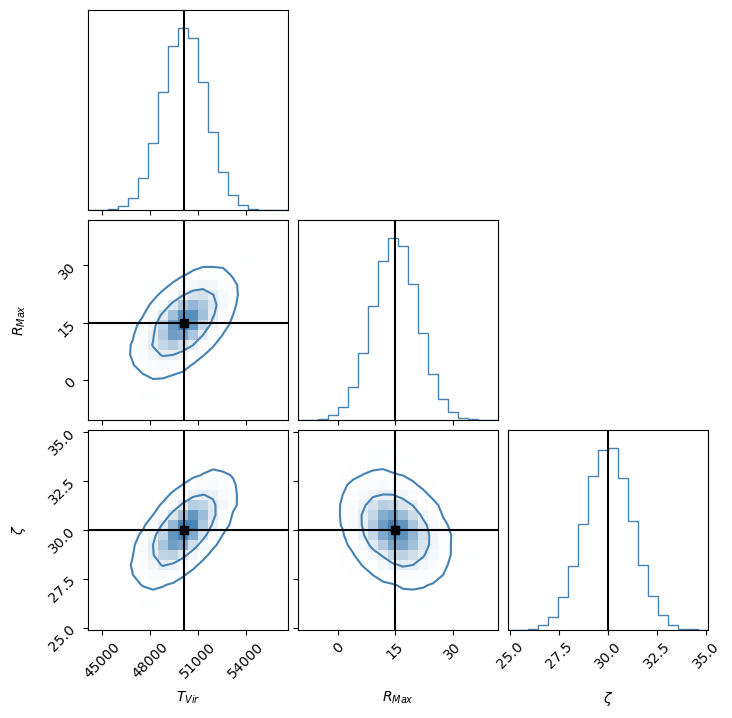

In [211]:
fisher_samples_AAstar_100h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AAstar_100h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='steelblue'           
)

In [212]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_beam_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AAstar_100hours_ps2d_beam_wedge.txt


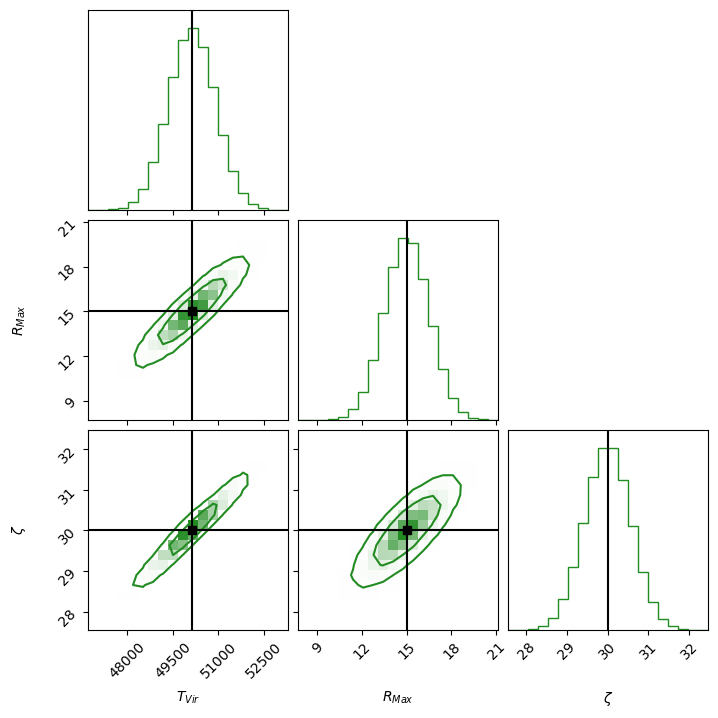

In [243]:
fisher_samples_AAstar_1000h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AAstar_1000h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='forestgreen'           
)

In [244]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_beam_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AAstar_1000hours_ps2d_beam_wedge.txt


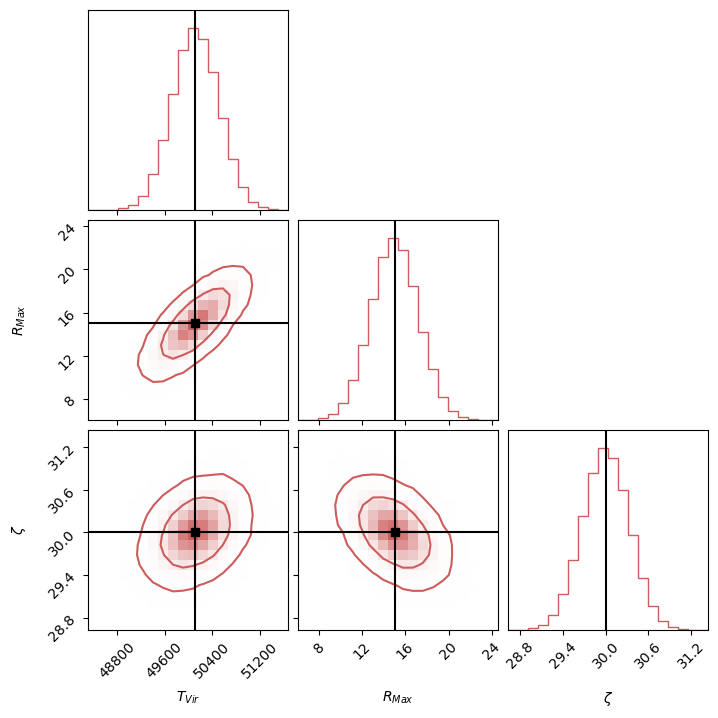

In [276]:
fisher_samples_AA4_1000h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AA4_1000h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='indianred'           
)

In [277]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_beam_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AA4_1000hours_ps2d_beam_wedge.txt


# horizon wedge

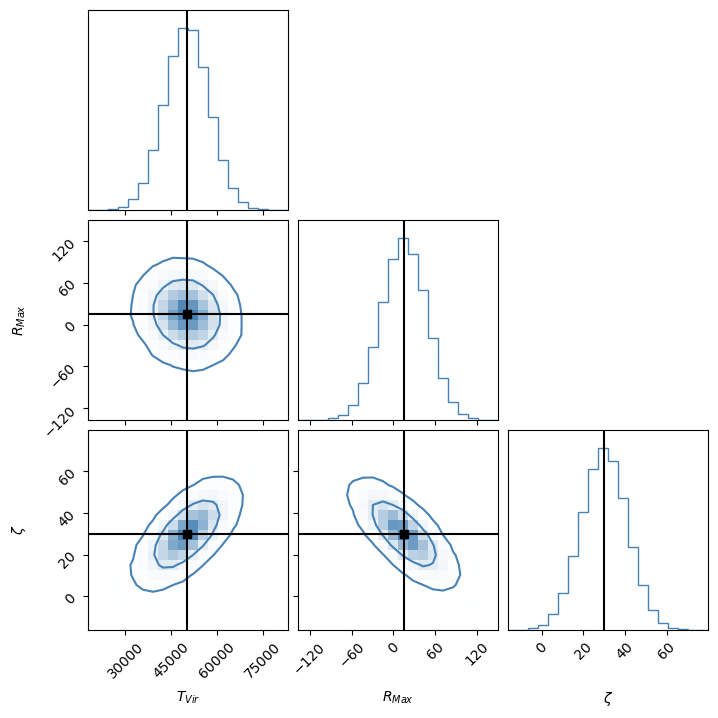

In [216]:
fisher_samples_AAstar_100h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AAstar_100h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='steelblue'           
)

In [217]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_horizon_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AAstar_100hours_ps2d_horizon_wedge.txt


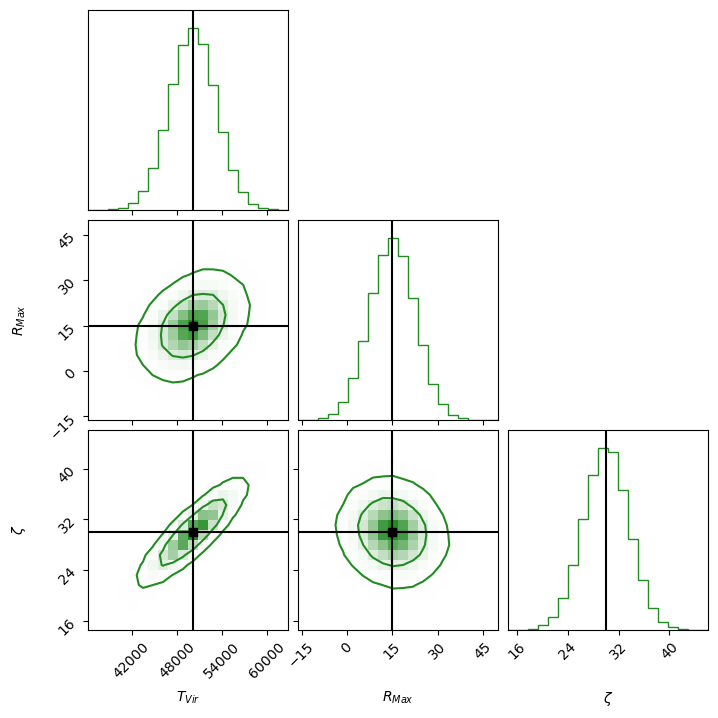

In [250]:
fisher_samples_AAstar_1000h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AAstar_1000h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='forestgreen'           
)

In [251]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_horizon_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AAstar_1000hours_ps2d_horizon_wedge.txt


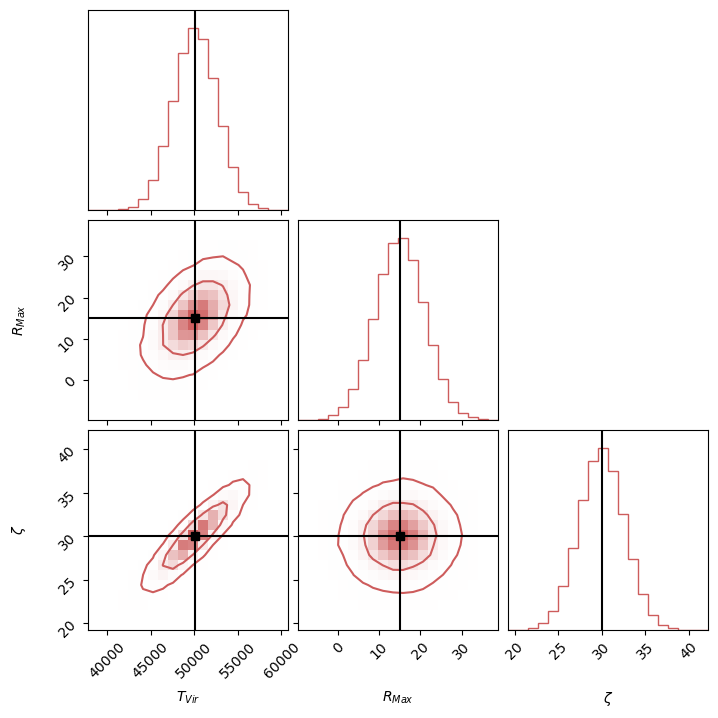

In [281]:
fisher_samples_AA4_1000h = np.random.multivariate_normal(fid, PS_Fisher_Inv[-1], size=100000)

_ = corner.corner(
    fisher_samples_AA4_1000h,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid,
    truth_color='black', 
    color='indianred'           
)

In [282]:
savefile = os.path.join(
    output_stat_dir,
    f'posterior_covariance_matrix_{telescope_type}_{obs_time}hours_{statname}2d_horizon_wedge.txt'
)
np.savetxt(savefile, PS_Fisher_Inv[-1])
print(savefile)

./SKA_chapter_statistics/posterior_covariance_matrix_AA4_1000hours_ps2d_horizon_wedge.txt
